# Test: glitch catalog from rates & priors

Draw a realistic glitch catalog with `catalog_generator.run_catalog` (which uses the LPF event **rate** and the empirical **parameter population**, with bounds/coordinate transforms taken from `priors.py`), save it to a `.npz`, reload it, and plot the parameter histograms.

In [1]:
import numpy as np
import jax.random as jr
import matplotlib.pyplot as plt

import jaxglitches as jg
from jaxglitches import catalog_generator as cg
from jaxglitches import priors

print(f"ordinary rate: {cg.RATE_ORDINARY:.3e} /s  ({cg.RATE_ORDINARY*86400:.2f} glitches/day)")
print(f"cold rate    : {cg.RATE_COLD:.3e} /s  ({cg.RATE_COLD*86400:.2f} glitches/day)")
print(f"prior bounds (lower, upper):")
lo, hi = priors.prior_bounds()
for name, l, h in zip(["t0 [s]", "Deltav [m/s]", "tau [s]"], np.asarray(lo), np.asarray(hi)):
    print(f"  {name:14s}: [{l:.3g}, {h:.3g}]")

ordinary rate: 4.973e-05 /s  (4.30 glitches/day)
cold rate    : 4.973e-04 /s  (42.96 glitches/day)
prior bounds (lower, upper):
  t0 [s]        : [0, 3.6e+03]
  Deltav [m/s]  : [1e-16, 1e-07]
  tau [s]       : [0.1, 5e+04]


## 1) Draw a catalog

One year of observation, ordinary-run rate. The number of events is `Poisson(rate * T_obs)`; arrival times are uniform over the window; `(Deltav, tau)` are resampled from the empirical LPF population; each event is placed at one of the six test-mass injection points.

In [2]:
YEAR = 365.25 * 24 * 3600.0
T_OBS = 1.0 * YEAR
RUN_TYPE = "ordinary"

print(f"expected count over {T_OBS/YEAR:.2f} yr: {jg.expected_count(T_OBS, RUN_TYPE):.1f}")

catalog = jg.run_catalog(T_OBS, key=jr.PRNGKey(20260707), run_type=RUN_TYPE)

print(f"drawn n_glitches = {catalog['n_glitches']}")
print(f"t0     [s]   : min {float(catalog['t0'].min()):.3g}  max {float(catalog['t0'].max()):.3g}")
print(f"|Deltav|[m/s]: median {float(np.median(np.abs(catalog['Deltav']))):.3g}")
print(f"tau    [s]   : median {float(np.median(catalog['tau'])):.3g}")
print(f"injection points used: {sorted(set(catalog['inj_point']))}")

expected count over 1.00 yr: 1569.2


drawn n_glitches = 1529
t0     [s]   : min 1.83e+04  max 3.15e+07
|Deltav|[m/s]: median 2.71e-13
tau    [s]   : median 1.22
injection points used: ['tm_12', 'tm_13', 'tm_21', 'tm_23', 'tm_31', 'tm_32']


## 2) Save the catalog to a `.npz`

Store the physical parameters (arrival time, velocity kick, damping time), the injection-point index, and a bit of metadata.

In [3]:
OUT = "glitch_catalog.npz"

np.savez(
    OUT,
    t0=np.asarray(catalog["t0"]),
    Deltav=np.asarray(catalog["Deltav"]),
    tau=np.asarray(catalog["tau"]),
    inj_idx=np.asarray(catalog["inj_idx"]),
    inj_points=np.asarray(cg.INJ_POINTS),
    t_obs=catalog["t_obs"],
    rate=catalog["rate"],
    run_type=RUN_TYPE,
)
print(f"saved {catalog['n_glitches']} glitches to {OUT}")

saved 1529 glitches to glitch_catalog.npz


## 3) Load the catalog and plot parameter histograms

In [4]:
data = np.load(OUT, allow_pickle=True)
t0 = data["t0"]
Deltav = data["Deltav"]
tau = data["tau"]
inj_idx = data["inj_idx"]
inj_points = list(data["inj_points"])
t_obs = float(data["t_obs"])
n = t0.size
print(f"loaded {n} glitches (rate {float(data['rate']):.3e}/s, run '{str(data['run_type'])}')")

loaded 1529 glitches (rate 4.973e-05/s, run 'ordinary')


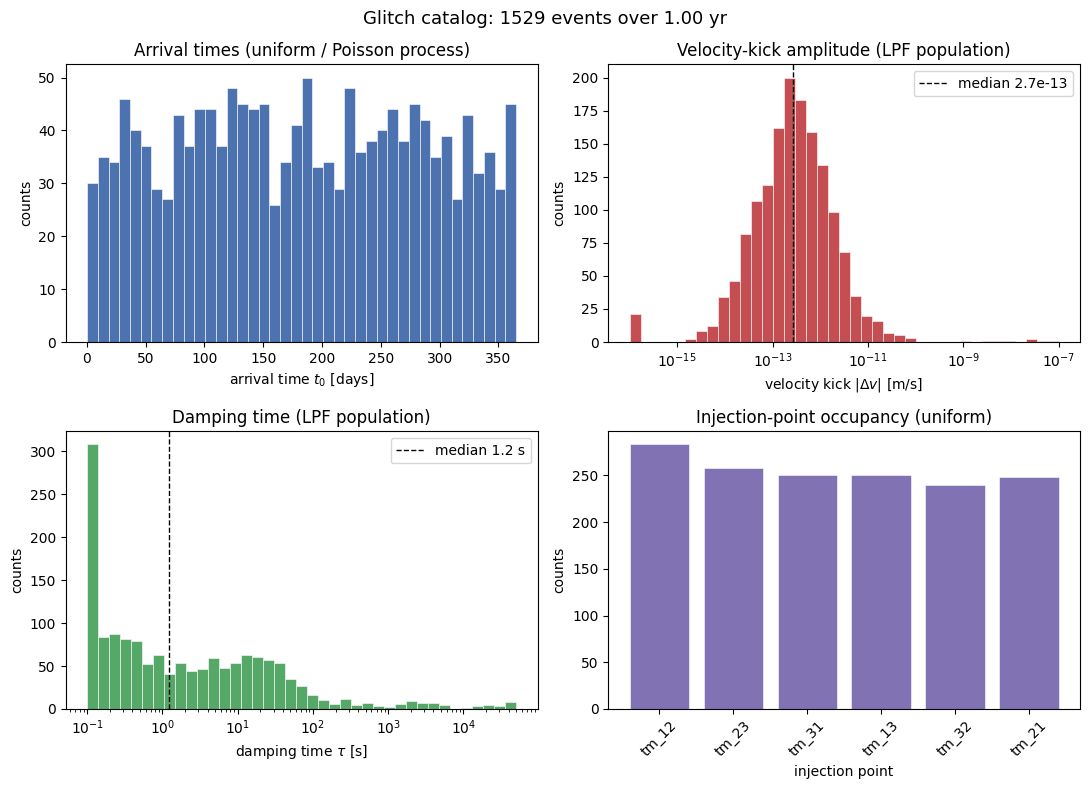

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

# Arrival time t0 -- should be uniform over the observation window
ax = axes[0, 0]
ax.hist(t0 / (24 * 3600.0), bins=40, color="#4C72B0", edgecolor="white", lw=0.4)
ax.set_xlabel("arrival time $t_0$ [days]")
ax.set_ylabel("counts")
ax.set_title("Arrival times (uniform / Poisson process)")

# Velocity kick |Deltav| -- log-spaced bins
ax = axes[0, 1]
adv = np.abs(Deltav)
bins = np.logspace(np.log10(adv.min()), np.log10(adv.max()), 40)
ax.hist(adv, bins=bins, color="#C44E52", edgecolor="white", lw=0.4)
ax.set_xscale("log")
ax.axvline(np.median(adv), color="k", ls="--", lw=1, label=f"median {np.median(adv):.2g}")
ax.set_xlabel(r"velocity kick $|\Delta v|$ [m/s]")
ax.set_ylabel("counts")
ax.set_title("Velocity-kick amplitude (LPF population)")
ax.legend()

# Damping time tau -- log-spaced bins
ax = axes[1, 0]
bins = np.logspace(np.log10(tau.min()), np.log10(tau.max()), 40)
ax.hist(tau, bins=bins, color="#55A868", edgecolor="white", lw=0.4)
ax.set_xscale("log")
ax.axvline(np.median(tau), color="k", ls="--", lw=1, label=f"median {np.median(tau):.2g} s")
ax.set_xlabel(r"damping time $\tau$ [s]")
ax.set_ylabel("counts")
ax.set_title("Damping time (LPF population)")
ax.legend()

# Injection point occupancy
ax = axes[1, 1]
counts = np.bincount(inj_idx, minlength=len(inj_points))
ax.bar(range(len(inj_points)), counts, color="#8172B3", edgecolor="white", lw=0.4)
ax.set_xticks(range(len(inj_points)))
ax.set_xticklabels(inj_points, rotation=45)
ax.set_xlabel("injection point")
ax.set_ylabel("counts")
ax.set_title("Injection-point occupancy (uniform)")

fig.suptitle(f"Glitch catalog: {n} events over {t_obs/YEAR:.2f} yr", fontsize=13)
fig.tight_layout()
plt.show()

### Cross-check: does the drawn population match the empirical LPF catalog?

Overlay the drawn `(tau, |Deltav|)` marginals against the raw LPF `effective_glitch_parameters` catalog that `catalog_generator` resamples.

5 LPF |level| values below the 1e-16 m/s drawn-catalog floor (min 6.2e-25) -- clipped into the first bin for the comparison.


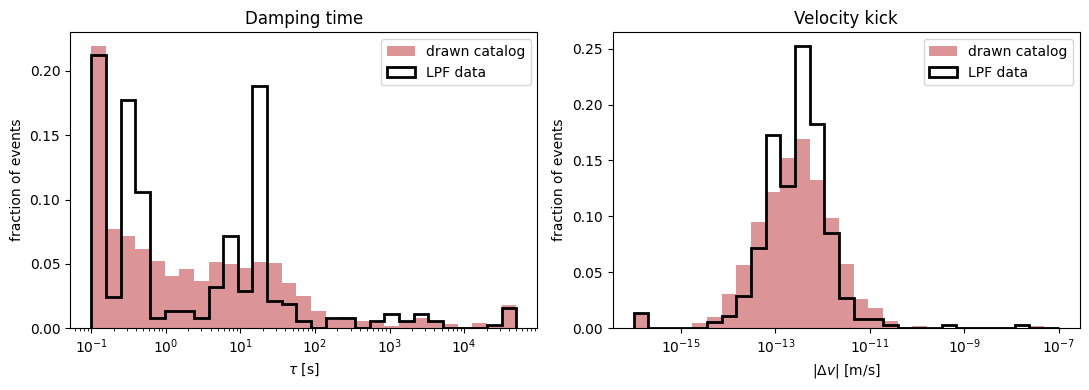

In [6]:
beta_lpf, level_lpf = cg._load_lpf_catalog(RUN_TYPE)
alevel_lpf = np.abs(level_lpf)

# Compare *shapes* on a log axis with fraction-of-events-per-bin normalisation.
# NB: do NOT use `density=True` here -- density divides by the *linear* bin width,
# which on log-spaced bins over-weights the narrow low-value bins by many orders
# of magnitude (a lone LPF outlier at ~6e-25 m/s otherwise makes one giant spike
# that hides everything else). `weights` -> each histogram sums to 1.
lo_dv, hi_dv = float(priors.prior_bounds()[0][1]), float(priors.prior_bounds()[1][1])   # Deltav bounds
lo_tau, hi_tau = float(priors.prior_bounds()[0][2]), float(priors.prior_bounds()[1][2])  # tau bounds

n_sub = int((alevel_lpf < lo_dv).sum())
print(f"{n_sub} LPF |level| values below the {lo_dv:.0e} m/s drawn-catalog floor "
      f"(min {alevel_lpf.min():.2g}) -- clipped into the first bin for the comparison.")

def frac_hist(ax, drawn, lpf, bins, xlabel, title):
    wd = np.ones_like(drawn) / drawn.size
    wl = np.ones_like(lpf) / lpf.size
    ax.hist(np.clip(drawn, bins[0], bins[-1]), bins=bins, weights=wd,
            alpha=0.6, color="#C44E52", label="drawn catalog")
    ax.hist(np.clip(lpf, bins[0], bins[-1]), bins=bins, weights=wl,
            histtype="step", lw=2, color="k", label="LPF data")
    ax.set_xscale("log")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("fraction of events")
    ax.set_title(title)
    ax.legend()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
frac_hist(axes[0], tau, beta_lpf, np.logspace(np.log10(lo_tau), np.log10(hi_tau), 30),
          r"$\tau$ [s]", "Damping time")
frac_hist(axes[1], adv, alevel_lpf, np.logspace(np.log10(lo_dv), np.log10(hi_dv), 30),
          r"$|\Delta v|$ [m/s]", "Velocity kick")
fig.tight_layout()
plt.show()